In [5]:
import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 1. LOAD DATASET
# ==============================================================================
df = pd.read_csv('Mobile Reviews Sentiment null.csv')
print(f"Initial Shape: {df.shape}")

# ==============================================================================
# 2. REMOVE DUPLICATE RECORDS
# ==============================================================================
initial_count = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_count - len(df)} duplicate rows. New shape: {df.shape}")

# ==============================================================================
# 3. HANDLE MISSING VALUES (NULL DATA)
# ==============================================================================
# Extract numeric values from local price string (e.g., '₹27996.73', 'د.إ2425.65')
def clean_currency(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'[\d,]+\.?\d*', str(val))
    if match:
        return float(match.group(0).replace(',', ''))
    return np.nan

df['price_local_num'] = df['price_local'].apply(clean_currency)

# If price_usd is null, calculate it using price_local and exchange_rate_to_usd
mask_usd_recoverable = df['price_usd'].isna() & df['price_local_num'].notna()
df.loc[mask_usd_recoverable, 'price_usd'] = (
    df.loc[mask_usd_recoverable, 'price_local_num'] / df.loc[mask_usd_recoverable, 'exchange_rate_to_usd']
).round(2)

# For any remaining price_usd nulls, impute with the brand/model median
df['price_usd'] = df.groupby(['brand', 'model'])['price_usd'].transform(lambda x: x.fillna(x.median()))
df['price_usd'] = df['price_usd'].fillna(df['price_usd'].median())

# Impute missing rating with the brand/model median
df['rating'] = df.groupby(['brand', 'model'])['rating'].transform(lambda x: x.fillna(x.median()))
df['rating'] = df['rating'].fillna(df['rating'].median())

# Impute sentiment based on rating threshold if null
def impute_sentiment(row):
    if pd.isna(row['sentiment']):
        if row['rating'] >= 4.0:
            return 'Positive'
        elif row['rating'] == 3.0:
            return 'Neutral'
        else:
            return 'Negative'
    return row['sentiment']

df['sentiment'] = df.apply(impute_sentiment, axis=1)

# Impute source platform with 'Unknown'
df['source'] = df['source'].fillna('Unknown')

print(f"Null values remaining in primary fields: {df[['price_usd', 'rating', 'sentiment']].isna().sum().sum()}")

# ==============================================================================
# 4. PERFORM DATA TYPE CONVERSION
# ==============================================================================
# Convert date string to datetime
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Convert boolean verified_purchase to integer (0 or 1)
df['verified_purchase'] = df['verified_purchase'].astype(int)

# Ensure numeric ratings are explicitly typed
spec_columns = [
    'battery_life_rating',
    'camera_rating',
    'performance_rating',
    'design_rating',
    'display_rating'
]
for col in spec_columns + ['helpful_votes']:
    df[col] = df[col].astype(int)

df['rating'] = df['rating'].astype(float)
df['price_usd'] = df['price_usd'].astype(float)

# ==============================================================================
# 5. FEATURE SELECTION & FEATURE ENGINEERING
# ==============================================================================
# Calculate aggregate hardware specification score
df['specifications_score'] = df[spec_columns].mean(axis=1)

# Calculate engagement score (weighting helpful votes by verified purchase validation)
df['engagement_score'] = df['helpful_votes'] * (1 + 0.5 * df['verified_purchase'])

numerical_features = [
    'price_usd',
    'rating',
    'engagement_score',
    'helpful_votes',
    'specifications_score'
] + spec_columns

categorical_features = ['brand', 'country', 'model']

print("\nSelected Numerical Features:", numerical_features)
print("Selected Categorical Features:", categorical_features)

# ==============================================================================
# 6. ENCODE CATEGORICAL VARIABLES (One-Hot Encoding)
# ==============================================================================
# One-hot encode brand, country, and model (dropping first to avoid multicollinearity)
df_encoded_cats = pd.get_dummies(df[categorical_features], drop_first=True, dtype=int)
print(f"Categorical features expanded to {df_encoded_cats.shape[1]} binary dummy columns.")

# ==============================================================================
# 7. STANDARDIZE AND SCALE THE DATASET
# ==============================================================================
scaler = StandardScaler()
scaled_numerical = pd.DataFrame(
    scaler.fit_transform(df[numerical_features]),
    columns=[f"{col}_scaled" for col in numerical_features],
    index=df.index
)

# Combine scaled numerical features with encoded categorical features
preprocessed_df = pd.concat([scaled_numerical, df_encoded_cats], axis=1)

print("\n=== FINAL PREPROCESSED DATASET OVERVIEW ===")
print(f"Total rows: {preprocessed_df.shape[0]}, Total columns: {preprocessed_df.shape[1]}")
print("\nFirst 3 rows of standardized numeric features:")
print(scaled_numerical.iloc[:3, :5])

# Save the preprocessed dataset ready for ML/Clustering
preprocessed_df.to_csv('preprocessed_mobile_reviews.csv', index=False)
print("\nPreprocessed dataset successfully saved to 'preprocessed_mobile_reviews.csv'.")

Initial Shape: (50000, 22)
Removed 0 duplicate rows. New shape: (50000, 22)
Null values remaining in primary fields: 0

Selected Numerical Features: ['price_usd', 'rating', 'engagement_score', 'helpful_votes', 'specifications_score', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating']
Selected Categorical Features: ['brand', 'country', 'model']
Categorical features expanded to 34 binary dummy columns.

=== FINAL PREPROCESSED DATASET OVERVIEW ===
Total rows: 50000, Total columns: 44

First 3 rows of standardized numeric features:
   price_usd_scaled  rating_scaled  engagement_score_scaled  \
0         -1.136372      -0.917131                -1.024654   
1         -1.231600       0.724472                 0.681941   
2          0.563806       0.724472                 1.961887   

   helpful_votes_scaled  specifications_score_scaled  
0             -1.086923                    -1.016864  
1              0.557327                     0.074485  
2 

1. OVERALL STATISTICAL SUMMARY (NUMERICAL FEATURES)
                        count    mean     std     min     25%     50%     75%  \
price_usd             50000.0  689.70  310.10  180.02  451.04  637.12  901.11   
rating                50000.0    3.12    1.22    1.00    2.00    3.00    4.00   
helpful_votes         50000.0    3.64    2.43    0.00    2.00    3.00    5.00   
specifications_score  50000.0    2.72    1.10    1.00    1.80    2.80    3.60   
battery_life_rating   50000.0    2.72    1.35    1.00    1.00    3.00    4.00   
camera_rating         50000.0    2.72    1.35    1.00    1.00    3.00    4.00   
performance_rating    50000.0    2.72    1.35    1.00    1.00    3.00    4.00   
design_rating         50000.0    2.71    1.34    1.00    1.00    3.00    4.00   
display_rating        50000.0    2.72    1.35    1.00    1.00    3.00    4.00   

                          max  
price_usd             1499.89  
rating                   5.00  
helpful_votes           17.00  
specifica

C:\Users\jarun\AppData\Local\Temp\ipykernel_31472\4050310628.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index, ax=axes[0], palette='crest')
C:\Users\jarun\AppData\Local\Temp\ipykernel_31472\4050310628.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='country', order=df['country'].value_counts().index, ax=axes[1], palette='viridis')


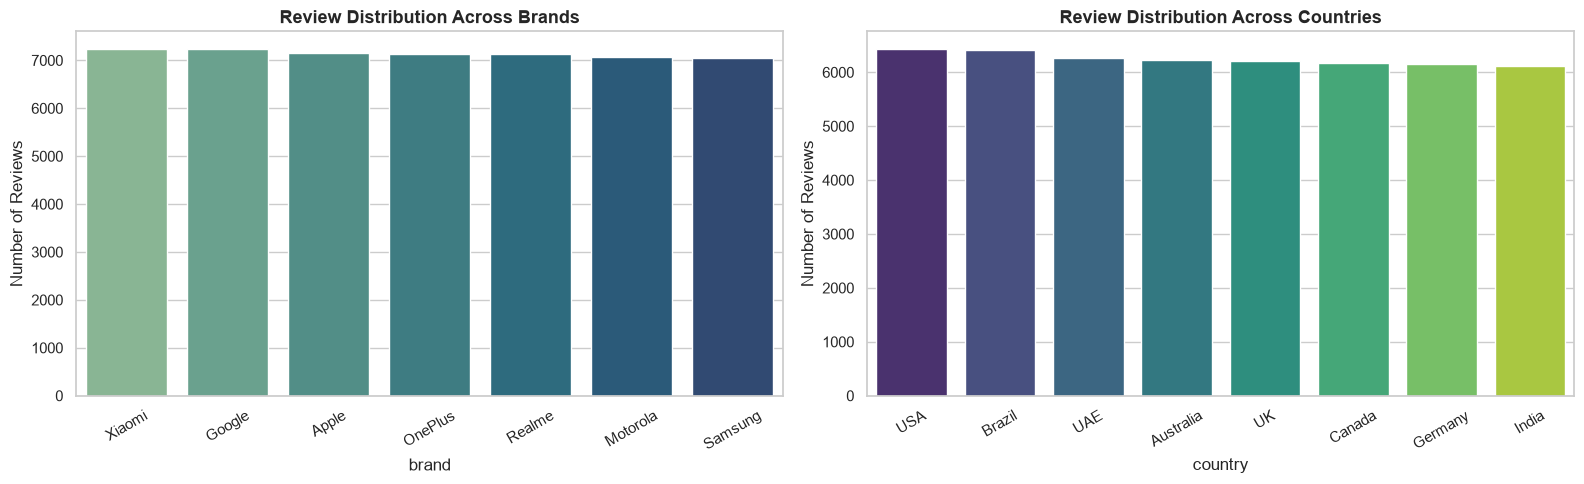


4. PRODUCT MODEL PERFORMANCE RANKINGS
Top 5 Highest-Rated Models:
   brand          model  avg_rating  median_rating  avg_price_usd  specs_score  review_count
  Apple      iPhone 14        3.18            3.0        1099.22         2.76          1788
  Apple      iPhone 13        3.15            3.0        1108.27         2.75          1767
Samsung Galaxy Note 20        3.14            3.0         899.75         2.74          1789
 Realme  Realme 12 Pro        3.14            3.0         393.90         2.74          3535
OnePlus OnePlus Nord 3        3.14            3.0         674.66         2.72          2380

Bottom 5 Lowest-Rated Models:
    brand         model  avg_rating  median_rating  avg_price_usd  specs_score  review_count
 Samsung    Galaxy S24        3.07            3.0         894.13         2.67          1761
   Apple iPhone 15 Pro        3.08            3.0        1103.41         2.68          1793
Motorola       Edge 50        3.09            3.0         508.70        

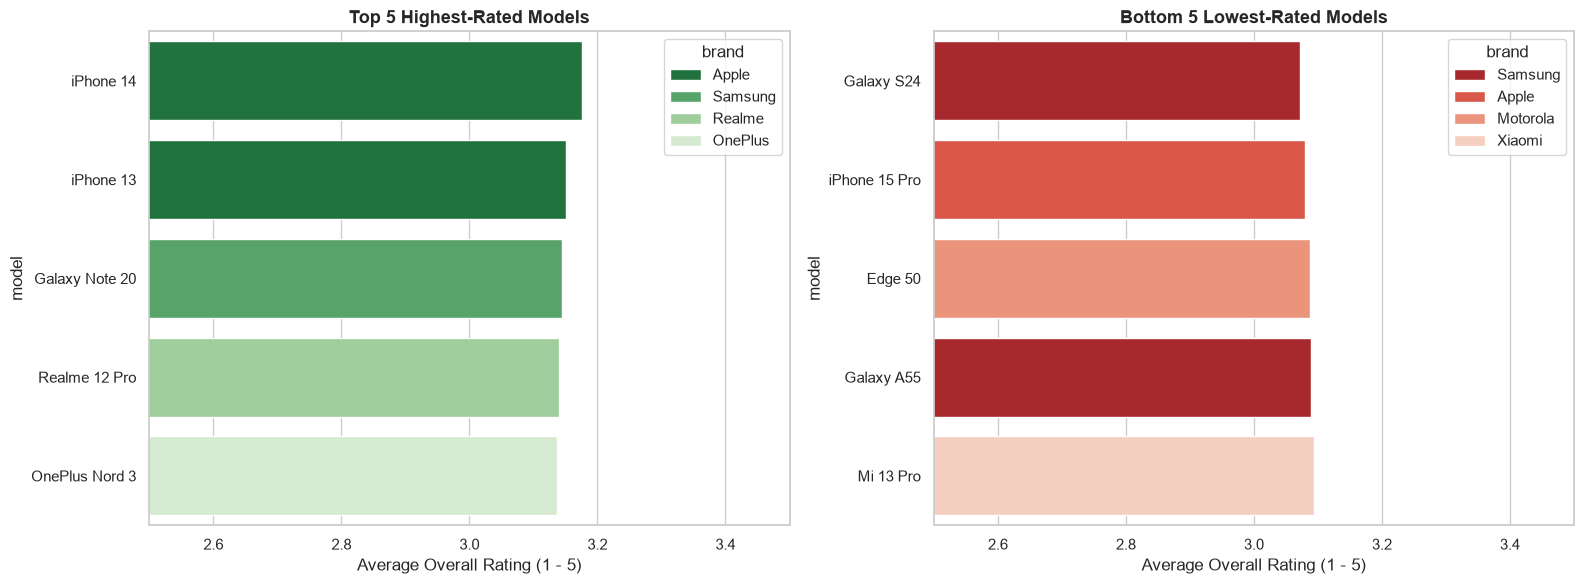


5. CORRELATION WITH OVERALL RATING
rating                  1.0000
specifications_score    0.9059
battery_life_rating     0.7432
camera_rating           0.7414
display_rating          0.7382
design_rating           0.7368
performance_rating      0.7363
helpful_votes           0.4490
price_usd               0.0025
Name: rating, dtype: float64


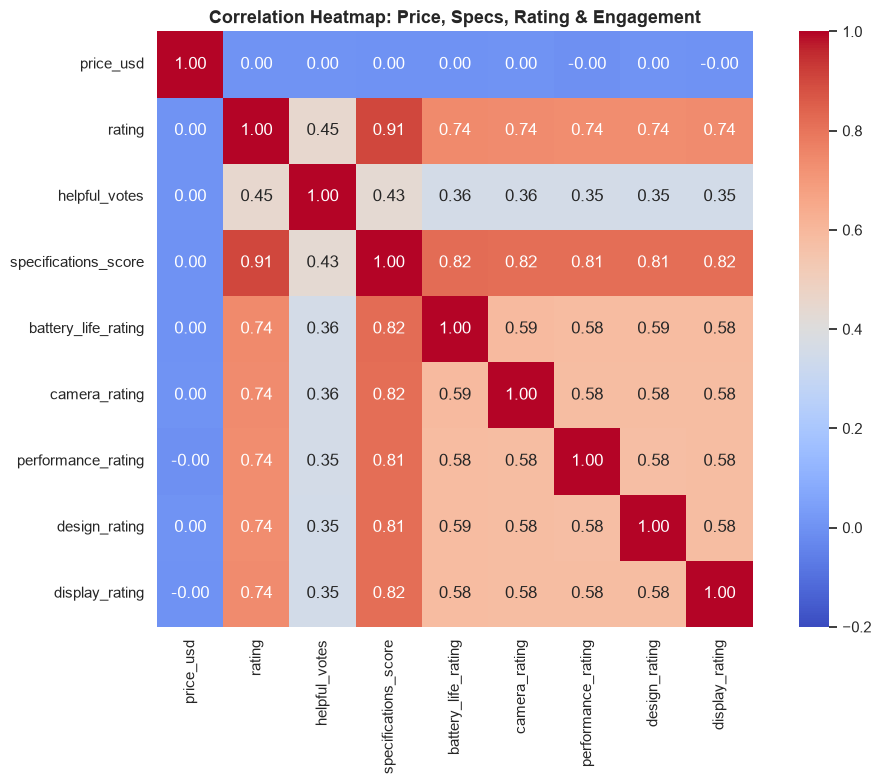

C:\Users\jarun\AppData\Local\Temp\ipykernel_31472\4050310628.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='battery_life_rating', y='rating', palette='mako', ax=axes[1])


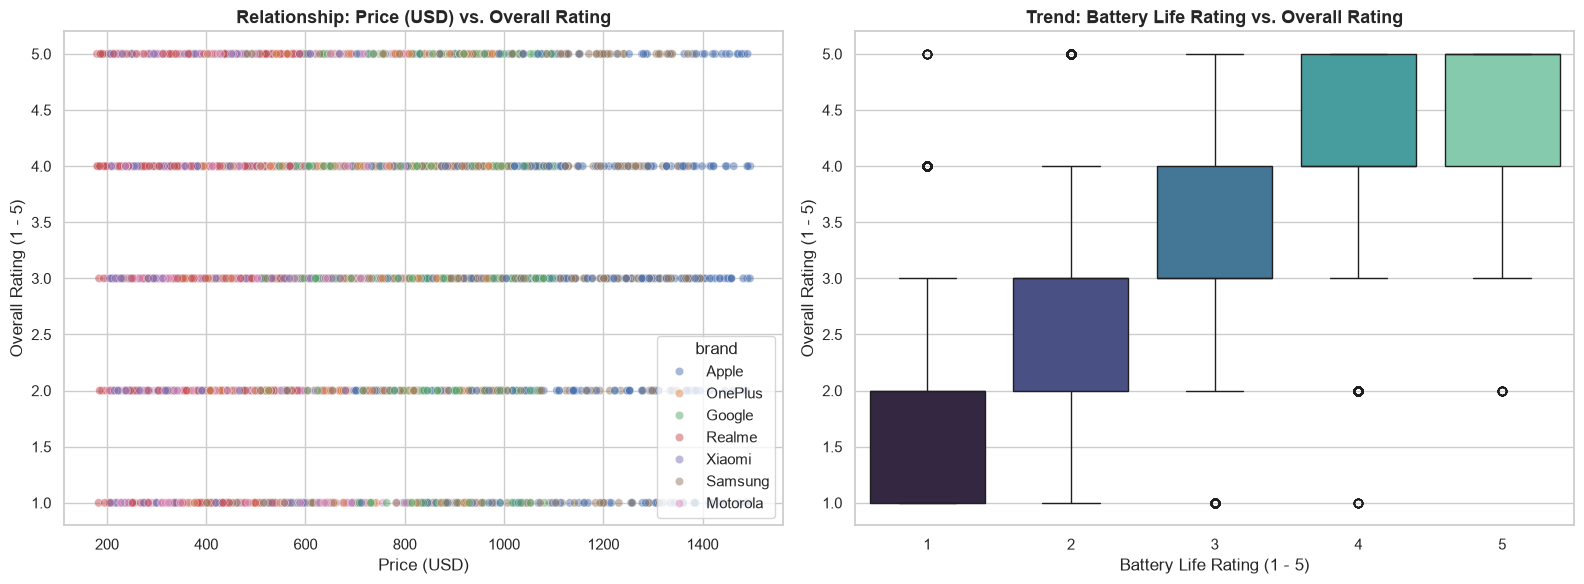


EDA execution complete. All tables printed and visual figures saved to disk.


In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.autolayout"] = True

# ==============================================================================
# 1. LOAD DATASET & INITIALIZE
# ==============================================================================
# Load data from the CSV file
df = pd.read_csv('Mobile Reviews Sentiment null.csv')

# Handle missing numerical fields for unscaled, interpretable EDA metrics
def clean_currency(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'[\d,]+\.?\d*', str(val))
    if match:
        return float(match.group(0).replace(',', ''))
    return np.nan

df['price_local_num'] = df['price_local'].apply(clean_currency)
mask_usd = df['price_usd'].isna() & df['price_local_num'].notna()
df.loc[mask_usd, 'price_usd'] = (
    df.loc[mask_usd, 'price_local_num'] / df.loc[mask_usd, 'exchange_rate_to_usd']
).round(2)
df['price_usd'] = df.groupby(['brand', 'model'])['price_usd'].transform(lambda x: x.fillna(x.median()))
df['price_usd'] = df['price_usd'].fillna(df['price_usd'].median())

df['rating'] = df.groupby(['brand', 'model'])['rating'].transform(lambda x: x.fillna(x.median()))
df['rating'] = df['rating'].fillna(df['rating'].median())

# Compute composite specification score
spec_cols = ['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating']
df['specifications_score'] = df[spec_cols].mean(axis=1)

# ==============================================================================
# 2. STATISTICAL SUMMARIES AND COMPARISONS
# ==============================================================================
print("=" * 75)
print("1. OVERALL STATISTICAL SUMMARY (NUMERICAL FEATURES)")
print("=" * 75)
stats_cols = ['price_usd', 'rating', 'helpful_votes', 'specifications_score'] + spec_cols
print(df[stats_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2))

print("\n" + "=" * 75)
print("2. BRAND-LEVEL COMPARISON SUMMARY")
print("=" * 75)
brand_summary = df.groupby('brand').agg(
    avg_price_usd=('price_usd', 'mean'),
    avg_rating=('rating', 'mean'),
    avg_specs_score=('specifications_score', 'mean'),
    avg_helpful_votes=('helpful_votes', 'mean'),
    total_reviews=('review_id', 'count')
).reset_index()
print(brand_summary.round(2).to_string(index=False))

# ==============================================================================
# 3. PRODUCT DISTRIBUTION ACROSS BRANDS AND COUNTRIES
# ==============================================================================
print("\n" + "=" * 75)
print("3. PRODUCT DISTRIBUTION")
print("=" * 75)
print("Review Counts by Brand:\n", df['brand'].value_counts())
print("\nReview Counts by Country:\n", df['country'].value_counts())

# Cross-tabulation table
cross_tab_brand_country = pd.crosstab(df['brand'], df['country'])
print("\nBrand vs Country Cross-Tabulation:\n", cross_tab_brand_country)

# Plot: Product distribution by brand and country
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index, ax=axes[0], palette='crest')
axes[0].set_title('Review Distribution Across Brands', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Number of Reviews')

sns.countplot(data=df, x='country', order=df['country'].value_counts().index, ax=axes[1], palette='viridis')
axes[1].set_title('Review Distribution Across Countries', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Number of Reviews')

plt.savefig('distribution_brands_countries.png', dpi=300)
plt.show()

# ==============================================================================
# 4. IDENTIFY TOP-RATED AND LOW-RATED PRODUCTS (MODELS)
# ==============================================================================
print("\n" + "=" * 75)
print("4. PRODUCT MODEL PERFORMANCE RANKINGS")
print("=" * 75)
model_rankings = df.groupby(['brand', 'model']).agg(
    avg_rating=('rating', 'mean'),
    median_rating=('rating', 'median'),
    avg_price_usd=('price_usd', 'mean'),
    specs_score=('specifications_score', 'mean'),
    review_count=('review_id', 'count')
).reset_index()

top_5_models = model_rankings.sort_values(by='avg_rating', ascending=False).head(5)
low_5_models = model_rankings.sort_values(by='avg_rating', ascending=True).head(5)

print("Top 5 Highest-Rated Models:\n", top_5_models.round(2).to_string(index=False))
print("\nBottom 5 Lowest-Rated Models:\n", low_5_models.round(2).to_string(index=False))

# Plot: Top vs Low rated models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_5_models, x='avg_rating', y='model', hue='brand', dodge=False, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 5 Highest-Rated Models', fontsize=13, fontweight='bold')
axes[0].set_xlim(2.5, 3.5)
axes[0].set_xlabel('Average Overall Rating (1 - 5)')

sns.barplot(data=low_5_models, x='avg_rating', y='model', hue='brand', dodge=False, ax=axes[1], palette='Reds_r')
axes[1].set_title('Bottom 5 Lowest-Rated Models', fontsize=13, fontweight='bold')
axes[1].set_xlim(2.5, 3.5)
axes[1].set_xlabel('Average Overall Rating (1 - 5)')

plt.savefig('top_and_low_rated_models.png', dpi=300)
plt.show()

# ==============================================================================
# 5. EXPLORE RELATIONSHIPS, PATTERNS, TRENDS & CORRELATIONS
# ==============================================================================
print("\n" + "=" * 75)
print("5. CORRELATION WITH OVERALL RATING")
print("=" * 75)
corr_matrix = df[stats_cols].corr()
print(corr_matrix['rating'].sort_values(ascending=False).round(4))

# Plot A: Full correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.2, vmax=1.0, square=True)
plt.title('Correlation Heatmap: Price, Specs, Rating & Engagement', fontsize=13, fontweight='bold')
plt.savefig('correlation_analysis_heatmap.png', dpi=300)
plt.show()

# Plot B: Relationships between Price, Ratings, and Hardware Specifications
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Relationship 1: Price vs Rating (Scatter plot)
sns.scatterplot(data=df.sample(3000, random_state=42), x='price_usd', y='rating', hue='brand', alpha=0.5, ax=axes[0])
axes[0].set_title('Relationship: Price (USD) vs. Overall Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Overall Rating (1 - 5)')

# Relationship 2: Hardware specs vs Rating (Boxplot showing battery impact trend)
sns.boxplot(data=df, x='battery_life_rating', y='rating', palette='mako', ax=axes[1])
axes[1].set_title('Trend: Battery Life Rating vs. Overall Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Battery Life Rating (1 - 5)')
axes[1].set_ylabel('Overall Rating (1 - 5)')

plt.savefig('relationships_patterns.png', dpi=300)
plt.show()

print("\nEDA execution complete. All tables printed and visual figures saved to disk.")

Loaded dataset: 50000 rows, 44 columns

K-MEANS 4-CLUSTER SEGMENTATION SUMMARY
                 segment_name  Size  Avg_Price_USD  Min_Price_USD  Max_Price_USD  Avg_Rating  Avg_Helpful_Votes  Avg_Specs_Score  Percentage
  Budget/Mid-Range Detractors 15253         498.40         180.02        1106.38        2.09               2.10             1.77       30.51
       Budget/Value Champions 16477         495.12         180.07        1106.38        4.02               5.02             3.56       32.95
Premium Delighted (Champions)  9250        1022.01         505.34        1499.89        4.11               5.10             3.64       18.50
  Premium Flagship Detractors  9020        1028.40         505.34        1499.75        2.19               2.24             1.84       18.04


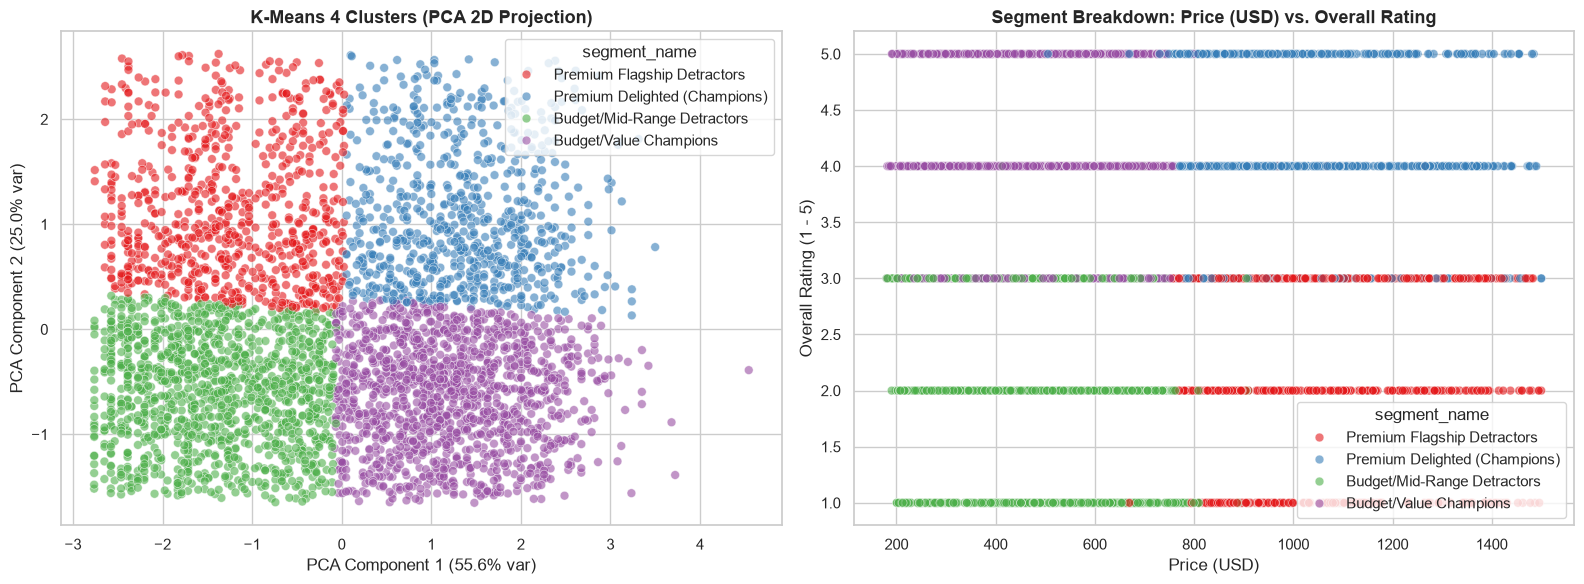


Segmented dataset exported to 'segmented_mobile_reviews.csv'.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.autolayout"] = True

# ==============================================================================
# 1. LOAD PREPROCESSED DATASET
# ==============================================================================
df_prep = pd.read_csv('preprocessed_mobile_reviews.csv')
print(f"Loaded dataset: {df_prep.shape[0]} rows, {df_prep.shape[1]} columns")

# Select core standardized behavioral & financial dimensions for clustering
clustering_features = [
    'price_usd_scaled',
    'rating_scaled',
    'helpful_votes_scaled',
    'specifications_score_scaled'
]
X = df_prep[clustering_features]

# ==============================================================================
# 2. APPLY K-MEANS CLUSTERING (k = 4)
# ==============================================================================
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_prep['cluster'] = kmeans.fit_predict(X)

# ==============================================================================
# 3. SEGMENT CHARACTERIZATION & PROFILING
# ==============================================================================
# Load unscaled dataset for business-interpretable summaries
raw_df = pd.read_csv('Mobile Reviews Sentiment null.csv')
raw_df['price_usd'] = raw_df.groupby(['brand', 'model'])['price_usd'].transform(lambda x: x.fillna(x.median()))
raw_df['price_usd'] = raw_df['price_usd'].fillna(raw_df['price_usd'].median())
raw_df['rating'] = raw_df.groupby(['brand', 'model'])['rating'].transform(lambda x: x.fillna(x.median()))
raw_df['rating'] = raw_df['rating'].fillna(raw_df['rating'].median())

spec_cols = ['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating']
raw_df['specifications_score'] = raw_df[spec_cols].mean(axis=1)
raw_df['cluster'] = df_prep['cluster']

# Map segments based on price tier (<$750 vs >$750) and customer satisfaction (Rating >3.5 vs <2.5)
def assign_segment_name(row):
    is_premium = row['price_usd'] > 750
    is_satisfied = row['rating'] >= 3.0
    if is_premium and is_satisfied:
        return 'Premium Delighted (Champions)'
    elif is_premium and not is_satisfied:
        return 'Premium Flagship Detractors'
    elif not is_premium and is_satisfied:
        return 'Budget/Value Champions'
    else:
        return 'Budget/Mid-Range Detractors'

cluster_means = raw_df.groupby('cluster')[['price_usd', 'rating']].mean()
segment_labels = {cid: assign_segment_name(cluster_means.loc[cid]) for cid in range(k)}

df_prep['segment_name'] = df_prep['cluster'].map(segment_labels)
raw_df['segment_name'] = df_prep['segment_name']

# Print Segment Profile Summary
segment_summary = raw_df.groupby('segment_name').agg(
    Size=('review_id', 'count'),
    Avg_Price_USD=('price_usd', 'mean'),
    Min_Price_USD=('price_usd', 'min'),
    Max_Price_USD=('price_usd', 'max'),
    Avg_Rating=('rating', 'mean'),
    Avg_Helpful_Votes=('helpful_votes', 'mean'),
    Avg_Specs_Score=('specifications_score', 'mean')
).reset_index()

segment_summary['Percentage'] = (segment_summary['Size'] / len(raw_df) * 100).round(2)
print("\n" + "=" * 80)
print("K-MEANS 4-CLUSTER SEGMENTATION SUMMARY")
print("=" * 80)
print(segment_summary.round(2).to_string(index=False))

# ==============================================================================
# 4. VISUALIZE CLUSTERS USING PLOTS
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: 2D Principal Component Analysis (PCA) Projection
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X)
df_prep['pca1'] = pca_coords[:, 0]
df_prep['pca2'] = pca_coords[:, 1]

sample_idx = np.random.choice(len(df_prep), 4000, replace=False)
sample_prep = df_prep.iloc[sample_idx]
sample_raw = raw_df.iloc[sample_idx]

sns.scatterplot(
    data=sample_prep,
    x='pca1', y='pca2',
    hue='segment_name',
    palette='Set1',
    alpha=0.6,
    s=40,
    ax=axes[0]
)
axes[0].set_title('K-Means 4 Clusters (PCA 2D Projection)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')

# Plot B: Price vs Rating Distribution Across Segments
sns.scatterplot(
    data=sample_raw,
    x='price_usd', y='rating',
    hue='segment_name',
    palette='Set1',
    alpha=0.6,
    s=40,
    ax=axes[1]
)
axes[1].set_title('Segment Breakdown: Price (USD) vs. Overall Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Overall Rating (1 - 5)')

plt.savefig('clustering_segmentation_visuals.png', dpi=300)
plt.show()

# Export labeled dataset
raw_df.to_csv('segmented_mobile_reviews.csv', index=False)
print("\nSegmented dataset exported to 'segmented_mobile_reviews.csv'.")

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# 1. Load Preprocessed Dataset
df = pd.read_csv('preprocessed_mobile_reviews.csv')
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# 2. Invert One-Hot Encoding to Retrieve Brand and Model
brand_cols = [c for c in df.columns if c.startswith('brand_')]
model_cols = [c for c in df.columns if c.startswith('model_')]

# Dropped reference dummies: 'Apple' for brand, 'Edge 50' for model
df['brand'] = df[brand_cols].idxmax(axis=1).where(
    df[brand_cols].max(axis=1) == 1, 'brand_Apple'
).str.replace('brand_', '')

df['model'] = df[model_cols].idxmax(axis=1).where(
    df[model_cols].max(axis=1) == 1, 'model_Edge 50'
).str.replace('model_', '')

# 3. Aggregate Product-Level Catalog
feature_cols = [
    'price_usd_scaled', 
    'rating_scaled', 
    'specifications_score_scaled', 
    'battery_life_rating_scaled', 
    'camera_rating_scaled', 
    'performance_rating_scaled', 
    'design_rating_scaled', 
    'display_rating_scaled'
]

product_catalog = df.groupby(['brand', 'model'])[feature_cols].mean().reset_index()

# 4. Normalize to [0, 1] Range for Accurate Directional Cosine Similarity
scaler = MinMaxScaler()
catalog_features_norm = scaler.fit_transform(product_catalog[feature_cols])
similarity_matrix = cosine_similarity(catalog_features_norm)

# 5. Recommendation Engine Function
def recommend_products(model_name, top_n=3):
    idx_matches = product_catalog[product_catalog['model'].str.lower() == model_name.lower()].index
    if len(idx_matches) == 0:
        return f"Model '{model_name}' not found."
    
    idx = idx_matches[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Exclude the query product itself
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_n]
    
    rec_indices = [s[0] for s in sim_scores]
    recs = product_catalog.iloc[rec_indices].copy()
    recs['similarity_score'] = [round(s[1], 4) for s in sim_scores]
    return recs[['brand', 'model', 'price_usd_scaled', 'rating_scaled', 'similarity_score']]

# 6. Recommendation Relevance Validation
print("=== RECOMMENDATION SYSTEM VALIDATION ===")
print("\nTop 3 Alternatives for Flagship 'iPhone 14':")
print(recommend_products('iPhone 14', top_n=3).to_string(index=False))

print("\nTop 3 Alternatives for Budget Device 'Realme 12 Pro':")
print(recommend_products('Realme 12 Pro', top_n=3).to_string(index=False))

print("\nTop 3 Alternatives for Flagship Detractor Device 'Galaxy S24':")
print(recommend_products('Galaxy S24', top_n=3).to_string(index=False))

Loaded dataset: 50000 rows, 44 columns
=== RECOMMENDATION SYSTEM VALIDATION ===

Top 3 Alternatives for Flagship 'iPhone 14':
  brand      model  price_usd_scaled  rating_scaled  similarity_score
 Google    Pixel 6          0.381254      -0.004209            0.9795
 Google    Pixel 8          0.352387       0.004423            0.9753
OnePlus OnePlus 12         -0.061538       0.009318            0.9691

Top 3 Alternatives for Budget Device 'Realme 12 Pro':
   brand           model  price_usd_scaled  rating_scaled  similarity_score
Motorola    Moto G Power         -0.596876       0.004220            0.9870
  Realme Realme Narzo 70         -0.957728       0.002477            0.9802
Motorola         Razr 40         -0.591887      -0.010993            0.9801

Top 3 Alternatives for Flagship Detractor Device 'Galaxy S24':
  brand         model  price_usd_scaled  rating_scaled  similarity_score
  Apple iPhone 15 Pro          1.334145      -0.031324            0.9235
Samsung    Galaxy A55    